# Investigate the Data

Welcome to the cumulative project on clustering algorithms! In this project, we will be investigating the way people think about masculinity by applying the KMeans algorithm to data from  <a href="https://fivethirtyeight.com/" target = "_blank">FiveThirtyEight</a>. FiveThirtyEight is a popular website known for their use of statistical analysis in many of their stories.

To begin, take a look at `masculinity-survey.pdf`. FiveThirtyEight and WNYC studios used this survey to get their male readers' thoughts on masculinity. After looking through some of the questions asked, take a look at FiveThirtyEight's article <a href="https://fivethirtyeight.com/features/what-do-men-think-it-means-to-be-a-man/" target = "_blank">What Do Men Think It Means To Be A Man?</a> to see their major takeaways. We're going to try to find more insights using machine learning.

In the code block below, we've loaded `masculinity.csv` into a DataFrame named `survey`. This file contains the raw responses to the masculinity survey. Let's start getting a sense of how this data is structured. Try to answer these questions using your Pandas knowledge:
* What are the names of the columns? How do those columns relate to the questions in the PDF?
* How many rows are there?
* How is a question with multiple parts, like question 7, represented in the DataFrame?
* How many people said they often ask a friend for professional advice? This is the first sub-question in question 7.

To answer that last question, use the `value_counts()` function. For example, `df["col_a"].value_counts()` gives you a nice summary of the values found in `"col_a"` of the DataFrame `df`.

You may also want to print `survey.head()` to get a sense of all of the columns.


In [61]:
import pandas as pd

survey = pd.read_csv('masculinity.csv')

In [62]:
print(survey.columns)

Index(['Unnamed: 0', 'StartDate', 'EndDate', 'q0001', 'q0002', 'q0004_0001',
       'q0004_0002', 'q0004_0003', 'q0004_0004', 'q0004_0005', 'q0004_0006',
       'q0005', 'q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004',
       'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 'q0007_0009',
       'q0007_0010', 'q0007_0011', 'q0008_0001', 'q0008_0002', 'q0008_0003',
       'q0008_0004', 'q0008_0005', 'q0008_0006', 'q0008_0007', 'q0008_0008',
       'q0008_0009', 'q0008_0010', 'q0008_0011', 'q0008_0012', 'q0009',
       'q0010_0001', 'q0010_0002', 'q0010_0003', 'q0010_0004', 'q0010_0005',
       'q0010_0006', 'q0010_0007', 'q0010_0008', 'q0011_0001', 'q0011_0002',
       'q0011_0003', 'q0011_0004', 'q0011_0005', 'q0012_0001', 'q0012_0002',
       'q0012_0003', 'q0012_0004', 'q0012_0005', 'q0012_0006', 'q0012_0007',
       'q0013', 'q0014', 'q0015', 'q0017', 'q0018', 'q0019_0001', 'q0019_0002',
       'q0019_0003', 'q0019_0004', 'q0019_0005', 'q0019_0006', 'q0019_0007',
      

**Question:** What are the names of the columns? How do those columns relate to the questions in the PDF?

**Answer**: These columns contain the answers to the PDF's questions. While some accept only one answer from a list of options (e.g. 'q0001' asks 'In general, how masculine or "manly" do you feel?'), others require the survey taker to respond to multiple parts (e.g. 'q0004_0xxx' has six parts concerning about some general aspects of their life, like activities and thoughts).

**Question:** How is a question with multiple parts, like question 7, represented in the DataFrame?

**Answer**: Questions like question 7 are likely represented as matrices, because their subfeatures function as columns and the survey takers who did (or didn't) respond are rows.

In [63]:
print(survey.info())

<class 'pandas.DataFrame'>
RangeIndex: 1189 entries, 0 to 1188
Data columns (total 98 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1189 non-null   int64  
 1   StartDate    1189 non-null   str    
 2   EndDate      1189 non-null   str    
 3   q0001        1189 non-null   str    
 4   q0002        1189 non-null   str    
 5   q0004_0001   1189 non-null   str    
 6   q0004_0002   1189 non-null   str    
 7   q0004_0003   1189 non-null   str    
 8   q0004_0004   1189 non-null   str    
 9   q0004_0005   1189 non-null   str    
 10  q0004_0006   1189 non-null   str    
 11  q0005        1189 non-null   str    
 12  q0007_0001   1189 non-null   str    
 13  q0007_0002   1189 non-null   str    
 14  q0007_0003   1189 non-null   str    
 15  q0007_0004   1189 non-null   str    
 16  q0007_0005   1189 non-null   str    
 17  q0007_0006   1189 non-null   str    
 18  q0007_0007   1189 non-null   str    
 19  q0007_0008   1189

**Question:** How many rows are there?

**Answer**: This dataset contains 1,189 rows, meaning 1,189 men participated in this survey. However, as shown above, a fair number of features contain null values. This implies that not everyone who took the survey was comfortable answering the questions (e.g. 'q0012' involved how one may respond to a case of sexual harassment, a very touchy subject).

In [64]:
print(survey['q0007_0001'].value_counts())

q0007_0001
Sometimes                    537
Rarely                       324
Often                        142
Never, but open to it        123
Never, and not open to it     53
No answer                     10
Name: count, dtype: int64


**Question:** How many people said they often ask a friend for professional advice?

**Answer:** Only 142 do so. Perhaps a perceived aspect of masculinity is pursuing a career independently, or at least not intimately.

# Mapping the Data

In order for us to start thinking about using the KMeans algorithm with this data, we need to first figure out how to turn these responses into numerical data. Let's once again consider question 7. We can't cluster the data using the phrases `"Often"` or `"Rarely"`, but we can turn those phrases into numbers. For example, we could map the data in the following way: 
* `"Often"` -> `4`
* `"Sometimes"` ->  `3`
* `"Rarely"` -> `2` 
* `"Never, but open to it"` -> `1`
* `"Never, and not open to it"` -> `0`.

Note that it's important that these responses are somewhat linear. `"Often"` is at one end of the spectrum with `"Never, and not open to it"` at the other. The other values fall in sequence between the two. You could perform a similar mapping for the `"educ4"` responses (question 29), but there isn't an obvious linear progression in the `"racethn4"` responses (question 28).

In order to do this transformation, use the `map()` function. `map()` takes a dictionary as a parameter. For example, the following line of code would turn all the `"A"`s into `1`s and all the `"B"`s into `2`s in the column `"col_one"`.

```py
df["col_one"] = df["col_one"].map({"A": 1, "B": 2})
```

We've given you a list of the columns that should be mapped. Loop through the values of the list and map each column using the mapping described above.

Be careful of your spelling! Punctuation and whitespace is important. Take a look at the `value_counts()` of one of these columns to see if the mapping worked.


In [65]:
cols_to_map = ['q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004',
               'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 'q0007_0009',
               'q0007_0010', 'q0007_0011']
for col in cols_to_map:
    survey[col] = survey[col].map({'Often': 4,
                                   'Sometimes': 3,
                                   'Rarely': 2,
                                   'Never, but open to it': 1,
                                   'Never, and not open to it': 0})
survey[cols_to_map].value_counts()

q0007_0001  q0007_0002  q0007_0003  q0007_0004  q0007_0005  q0007_0006  q0007_0007  q0007_0008  q0007_0009  q0007_0010  q0007_0011
0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0           3
                                                            4.0         0.0         0.0         0.0         0.0         0.0           2
3.0         3.0         2.0         2.0         0.0         3.0         0.0         3.0         4.0         2.0         3.0           2
                        3.0         3.0         0.0         3.0         0.0         3.0         3.0         1.0         3.0           2
                                    2.0         1.0         3.0         0.0         4.0         3.0         1.0         2.0           2
                                                                                                                                     ..
4.0         4.0         3.0         3.0         0.0  

# Plotting the Data

We now have 11 different features that we could use in our KMeans algorithm. Before we jump into clustering, let's graph some of these features on a 2D graph. Call `plt.scatter` using `survey["q0007_0001"]` and `survey["q0007_0002"]` as parameters. Include `alpha = 0.1`. We want to include `alpha` because many of the data points will be on top of each other. Adding `alpha` will make the points appear more solid if there are many stacked on top of each other.

Include axis labels on your graph. The x-axis corresponds with the first column you gave the `scatter()` function. So in this case, it corresponds to the question about asking a friend for professional advice.

Does it make sense that there are few points in the top left and bottom right corners of the graph? Why? Try graphing other dimensions against each other. Are there any combinations that give you surprising results?


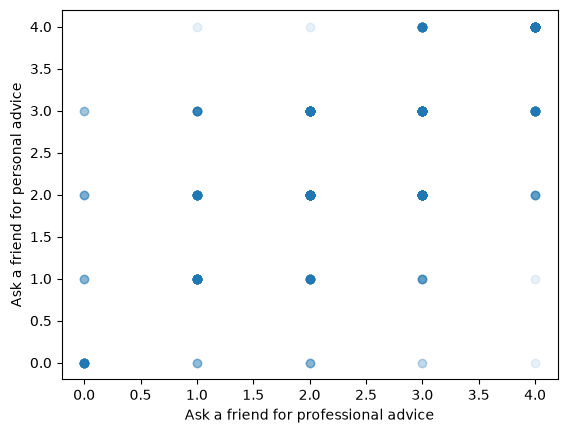

In [66]:
from matplotlib import pyplot as plt
plt.scatter(survey['q0007_0001'], survey['q0007_0002'], alpha=0.1)
plt.xlabel('Ask a friend for professional advice')
plt.ylabel('Ask a friend for personal advice')
plt.show()

**Observations:**
* No one in this survey asked a friend for personal advice alone. There seems to be a mix of requests for personal and professional advice in tandem.
* There seems to be a neighbourhood of men who sometimes and never (though they're open to it) ask their friends for both types of advice.

# Build the KMeans Model

It's now time to start clustering! There are so many interesting questions we could ask about this data. Let's start by seeing if clusters form based on traditionally masculine concepts. 

Take a look at the first four sub-questions in question 7. Those four activities aren't necessarily seen as traditionally masculine. On the other hand, sub-questions 5, 8, and 9 are often seen as very masculine activities. What would happen if we found 2 clusters based on those 7 questions? Would we find clusters that represent traditionally feminine and traditionally masculine people? Let's find out.

We need to first drop all of the rows that contain a `NaN` value in any of the columns we're interested in. Create a new variable named `rows_to_cluster` and set it equal to the result of calling `dropna` on `survey`. `dropna` should have a parameter `subset` equal to a list of the 7 columns we want. If you don't include `subset`, the function will drop all rows that have an `NaN` in *any* column. This would drop almost all the rows in the dataframe!

Create a `KMeans` object named `classifier` where `n_clusters = 2`. Call `classifier`'s `.fit()` method. The parameter of `.fit()` should be the 7 columns we're interested in. For example, the following line of code will fit the model based on the columns `"col_one"` and `"col_two"` of the Dataframe `df`. 

```py
classifier.fit(df[["col_one", "col_two"]])
```

Make sure to only include the columns that you want to train off of. Make sure to use `rows_to_cluster` rather than `survey` to avoid including those `NaN`s!



After fitting your model, print out the model's `cluster_centers_`.


In [67]:
cols_of_interest = ['q0007_0001', 'q0007_0002', 'q0007_0003',
                    'q0007_0006', 'q0007_0007', 'q0007_0010',
                    'q0007_0011']
rows_to_cluster = survey.dropna(subset=cols_of_interest)

In [68]:
from sklearn.cluster import KMeans
classifier = KMeans(n_clusters=2)
classifier.fit(rows_to_cluster[cols_of_interest])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 7)",

In [69]:
print(classifier.cluster_centers_)

[[1.9638009  1.92533937 1.08144796 3.04751131 0.0520362  0.59276018
  1.59954751]
 [2.87237237 2.84684685 2.87237237 2.65615616 0.54354354 1.57507508
  2.42642643]]


# Separate the Cluster Members

When we look at the two clusters, the first four numbers represent the traditionally feminine activities and the last three represent the traditionally masculine activities. If the data points separated into a feminine cluser and a masculine cluseter, we would expect to see one cluster to have high values for the first four numbers and the other cluster to have high values for the last three numbers.

Instead, the first cluster has a higher value in every feature. Since a higher number means the person was more likely to "often" do something, the clusters seem to represent "people who do things" and "people who don't do things".

We might be able to find out more information about these clusters by looking at the specific members of each cluster. Print `classifier.labels_`. This list shows which cluster every row in the DataFrame corresponds to.

For example,  if `classifier.labels_` was `[1, 0 ,1]`, then the first row in the DataFrame would be in cluster one, the second row would be in cluster 0, and the third row would be in cluster one. A row represents one persons answers to every question in the survey.

Create two new empty lists named `cluster_zero_indices` and `cluster_one_indices`. Loop through `classifier.labels_` and whenever a label is `0` add that index to `cluster_zero_indices`. Do the same whenever a label is a `1`.

Print `cluster_zero_indices`

In [70]:
print(classifier.labels_)

[1 1 0 ... 0 0 0]


In [71]:
cluster_zero_indices, cluster_one_indices = [], []
for i in range(len(classifier.labels_)):
    if classifier.labels_[i]==0:
        cluster_zero_indices.append(i)
    elif classifier.labels_[i]==1:
        cluster_one_indices.append(i)

In [72]:
print(cluster_zero_indices)

[2, 3, 4, 5, 6, 8, 11, 14, 16, 17, 18, 19, 21, 26, 28, 32, 35, 42, 47, 48, 50, 51, 52, 53, 54, 56, 57, 62, 63, 64, 65, 68, 71, 75, 79, 86, 87, 89, 90, 91, 92, 94, 95, 97, 98, 102, 107, 108, 112, 114, 117, 121, 125, 131, 132, 133, 134, 136, 141, 143, 144, 145, 146, 151, 157, 166, 171, 174, 178, 179, 183, 186, 191, 192, 193, 195, 197, 201, 203, 204, 206, 207, 208, 209, 211, 213, 215, 218, 235, 237, 239, 242, 243, 246, 247, 254, 255, 256, 266, 267, 270, 275, 278, 281, 285, 289, 290, 291, 297, 303, 305, 307, 308, 309, 312, 313, 318, 320, 325, 327, 331, 333, 335, 344, 345, 346, 347, 349, 351, 358, 359, 361, 367, 368, 371, 373, 374, 375, 376, 377, 380, 382, 385, 386, 394, 398, 399, 400, 401, 402, 406, 407, 408, 410, 413, 415, 420, 421, 423, 428, 429, 430, 431, 440, 441, 442, 444, 446, 448, 452, 462, 464, 465, 468, 471, 472, 473, 474, 475, 477, 478, 480, 481, 488, 491, 492, 493, 494, 496, 497, 498, 499, 503, 505, 506, 510, 511, 512, 513, 514, 517, 520, 521, 522, 523, 526, 528, 533, 534, 535, 

# Investigate the Cluster Members

Now that we have the indices for each cluster, let's look at some stats about these two clusters. You can get the rows of the DataFrame that correspond to cluster zero by doing the following:

```py
cluster_zero_df = rows_to_cluster.iloc[cluster_zero_indices]
```

Do the same for `cluster_one_df`.

Finally, let's look at some information about these two clusters. Print the `value_counts()` of the `educ4` column of each cluster. What do you notice? Try looking at different columns. For example, are the people in cluster zero significantly older than those in cluster one? You can look at the `age3` column to see.

If you divide the result of `value_counts()` by the size of the cluster, you get the percentage of people in each category rather than the total number. This will make it easier to compare the two clusters.

In [73]:
cluster_zero_df = rows_to_cluster.iloc[cluster_zero_indices]
cluster_one_df = rows_to_cluster.iloc[cluster_one_indices]

In [74]:
print(cluster_zero_df['educ4'].value_counts()/len(cluster_zero_df))
print('\n')
print(cluster_one_df['educ4'].value_counts()/len(cluster_one_df))

educ4
College or more         0.328798
Some college            0.283447
Post graduate degree    0.278912
High school or less     0.106576
Name: count, dtype: float64


educ4
Post graduate degree    0.364318
College or more         0.310345
Some college            0.236882
High school or less     0.088456
Name: count, dtype: float64


**Observations:**
* Males in cluster 1 is proportionately more likely to have a postgraduate degree from males in cluster 0.
* In both clusters, males are the least likely to have a high school education or lower.

In [75]:
print(cluster_zero_df['age3'].value_counts()/len(cluster_zero_df))
print('\n')
print(cluster_one_df['age3'].value_counts()/len(cluster_one_df))

age3
65 and up    0.555556
35 - 64      0.394558
18 - 34      0.047619
Name: count, dtype: float64


age3
35 - 64      0.503748
65 and up    0.425787
18 - 34      0.070465
Name: count, dtype: float64


**Observations:**
* Males in cluster 0 are proportionately more likely to be 65 years or older than males in cluster 1.
* Few males in both clusters are in their early 20s to early 30s.

# Explore on Your Own

Great work! You've found out that by answering those 7 questions people don't fall into a "masculine" category or a "feminine" category. Instead, they seem to be divided by their level of education!

Now it's time for you to explore this data on your own. In this project, we've really focused on question 7 and its sub-questions. Take a look at some of the other questions in the survey and try to ask yourself some interesting questions. Here's a list of questions you could dive into:

* Which demographic features have stronger correlations with ideas of masculinity (sexual orientation, age, race, marital status, parenthood?)
* Are certain beliefs or actions linked to more self-described masculine or feminine individuals?
* How do insecurities change as people grow older?


Special thanks to the team at FiveThirtyEight and specifically Dhrumil Mehta for giving us access to the data!


### Which demographic features have stronger correlations with ideas of masculinity (sexual orientation, age, race, marital status, parenthood)?

#### Select Features

In [76]:
demographics = [
    'q0024', # 'Married', 'Widowed', 'Divorced', 'Separated', or 'Never married'
    'kids', # 'Has children' or 'No children'
    'racethn4', # 'White', 'Hispanic', 'Black', or 'Other'
    'orientation', # 'Straight' or 'Gay/Bisexual'
    'age3', # '18 - 34', '35 - 64', or '65 and up'
]

In [77]:
masculinity = [
    'q0001' # 'Very masculine', 'Somewhat masculine', 'Not very masculine', 'Not at all masculine'
]

### Prepare and Clean Data

In [78]:
print('Duplicate values in original dataset:', survey.duplicated().sum())
print('Missing values in original dataset:')
print(survey.isna().sum())

Duplicate values in original dataset: 0
Missing values in original dataset:
Unnamed: 0     0
StartDate      0
EndDate        0
q0001          0
q0002          0
              ..
educ4          1
age3           1
kids           6
orientation    1
weight         1
Length: 98, dtype: int64


In [79]:
survey_subset1 = survey[demographics+masculinity].copy()
survey_subset1 # preview before removing missing and replacing corrupted values

,q0024,kids,racethn4,orientation,age3,q0001
0,Never married,No children,Hispanic,Gay/Bisexual,35 - 64,Somewhat masculine
1,Widowed,Has children,White,Straight,65 and up,Somewhat masculine
2,Married,Has children,White,Straight,35 - 64,Very masculine
3,Married,Has children,White,No answer,65 and up,Very masculine
4,Never married,No children,White,Straight,35 - 64,Very masculine
...,...,...,...,...,...,...
1184,Divorced,No children,Other,Gay/Bisexual,35 - 64,Somewhat masculine
1185,Married,Has children,White,Straight,35 - 64,Somewhat masculine
1186,Married,Has children,White,Straight,65 and up,Very masculine
1187,Never married,No children,Other,Straight,18 - 34,Somewhat masculine


In [80]:
import numpy as np
survey_subset1 = survey_subset1.replace('No answer', np.nan)
survey_subset1['racethn4'] = survey_subset1['racethn4'].replace('W', 'White') # because 'White' begins with 'W'
survey_subset1 = survey_subset1.dropna()

In [81]:
# Ordinal variables
survey_subset1['age3'] = survey_subset1['age3'].map({'18 - 34': 0,
                                                     '35 - 64': 1,
                                                     '65 and up': 2})
survey_subset1['q0001'] = survey_subset1['q0001'].map({'Not at all masculine': 0,
                                                       'Not very masculine': 1,
                                                       'Somewhat masculine': 2,
                                                       'Very masculine': 3})

In [82]:
# Binary variables
survey_subset1['kids'] = survey_subset1['kids'].map({'No children': 0,
                                                     'Has children': 1})

In [83]:
# Dummy variables
survey_subset1 = pd.get_dummies(survey_subset1,
                                columns=['q0024', 'racethn4', 'orientation'],
                                dtype=int)

In [84]:
survey_subset1.isna().sum() 

kids                        0
age3                        0
q0001                       0
q0024_Divorced              0
q0024_Married               0
q0024_Never married         0
q0024_Separated             0
q0024_Widowed               0
racethn4_Black              0
racethn4_Hispanic           0
racethn4_Other              0
racethn4_White              0
orientation_Gay/Bisexual    0
orientation_Other           0
orientation_Straight        0
dtype: int64

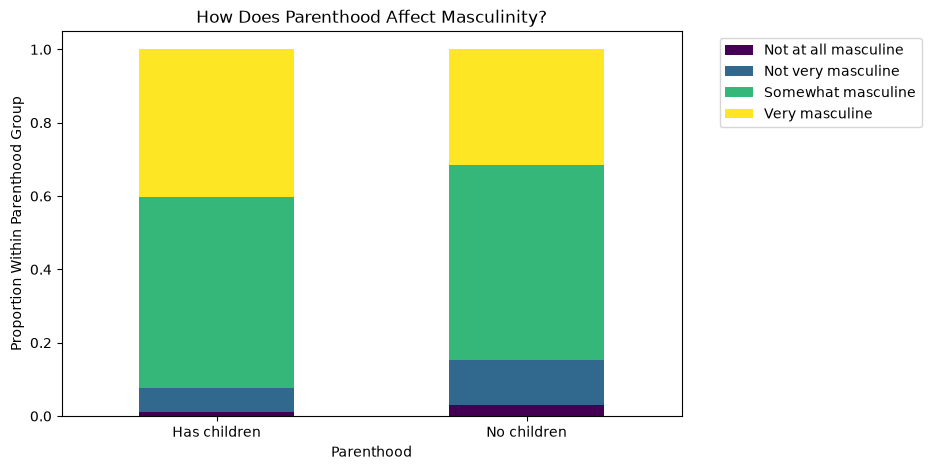

In [85]:
# The child-masculinity relationship
kids_labels = survey_subset1['kids'].map({0: 'No children',
                                          1: 'Has children'})

kids_proportions = pd.crosstab(kids_labels,
                               survey_subset1['q0001'],
                               normalize='index')
kids_proportions.columns = ['Not at all masculine', 'Not very masculine', 'Somewhat masculine', 'Very masculine']
kids_proportions.plot(kind='bar',
                      stacked=True,
                      figsize=(8, 5),
                      colormap='viridis')
plt.xlabel('Parenthood')
plt.ylabel('Proportion Within Parenthood Group')
plt.title('How Does Parenthood Affect Masculinity?')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
plt.show()

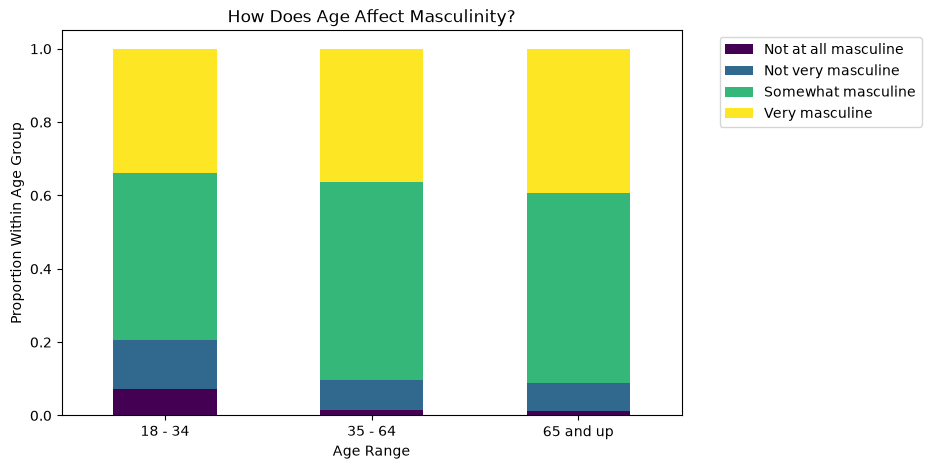

In [86]:
# The age-masculinity relationship
age_labels = survey_subset1['age3'].map({0: '18 - 34',
                                          1: '35 - 64',
                                          2: '65 and up'})
age_proportions = pd.crosstab(age_labels,
                              survey_subset1['q0001'],
                              normalize='index')
age_proportions.columns = ['Not at all masculine', 'Not very masculine', 'Somewhat masculine', 'Very masculine']
age_proportions.plot(kind='bar',
                      stacked=True,
                      figsize=(8, 5),
                      colormap='viridis')
plt.xlabel('Age Range')
plt.ylabel('Proportion Within Age Group')
plt.title('How Does Age Affect Masculinity?')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
plt.show()

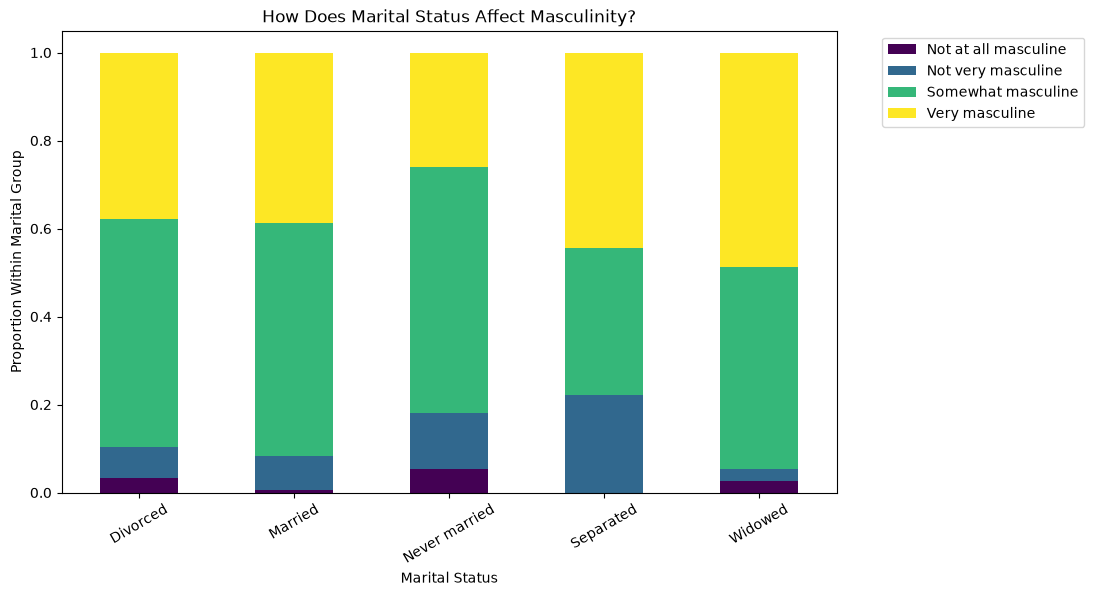

In [87]:
# The marital status-masculinity relationship
marital_columns = ['q0024_Divorced', 'q0024_Married', 'q0024_Never married', 'q0024_Separated', 'q0024_Widowed']
marital_status = survey_subset1[marital_columns].idxmax(axis=1).str.replace('q0024_', '', regex=False)
marital_proportions = pd.crosstab(marital_status,
                                  survey_subset1['q0001'],
                                  normalize='index')
marital_proportions.columns = ['Not at all masculine', 'Not very masculine', 'Somewhat masculine', 'Very masculine']
marital_proportions.plot(kind='bar',
                         stacked=True,
                         figsize=(10, 6),
                         colormap='viridis')
plt.xlabel('Marital Status')
plt.ylabel('Proportion Within Marital Group')
plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
plt.title('How Does Marital Status Affect Masculinity?')
plt.xticks(rotation=30)
plt.show()

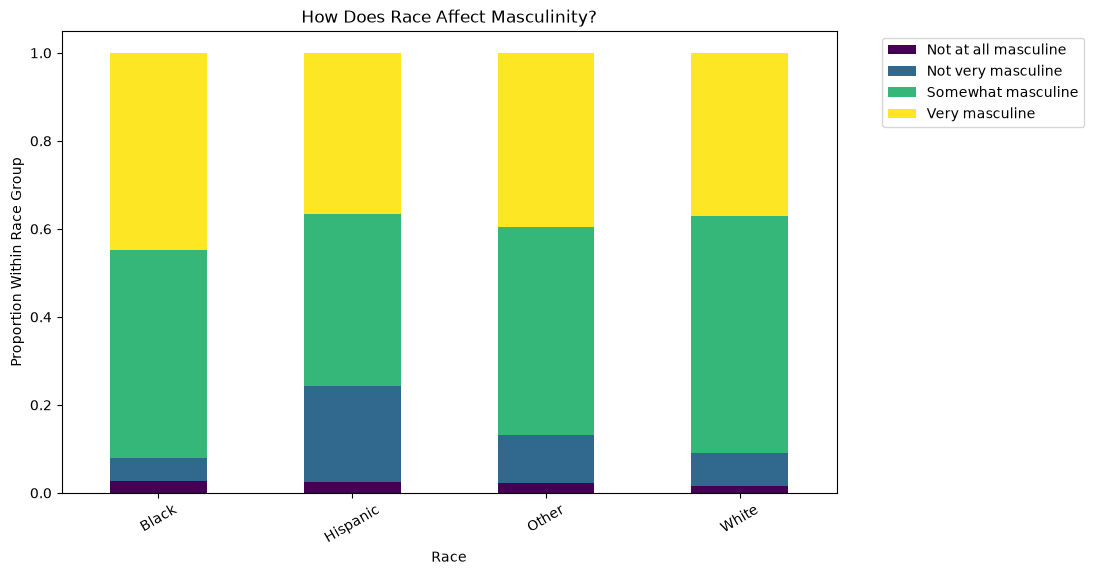

In [88]:
# The race-masculinity relationship
race_columns = ['racethn4_Black', 'racethn4_Hispanic', 'racethn4_Other', 'racethn4_White']
race_status = survey_subset1[race_columns].idxmax(axis=1).str.replace('racethn4_', '', regex=False)
race_proportions = pd.crosstab(race_status,
                               survey_subset1['q0001'],
                               normalize='index')
race_proportions.columns = ['Not at all masculine', 'Not very masculine', 'Somewhat masculine', 'Very masculine']
race_proportions.plot(kind='bar',
                      stacked=True,
                      figsize=(10, 6),
                      colormap='viridis')
plt.xlabel('Race')
plt.ylabel('Proportion Within Race Group')
plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
plt.title('How Does Race Affect Masculinity?')
plt.xticks(rotation=30)
plt.show()

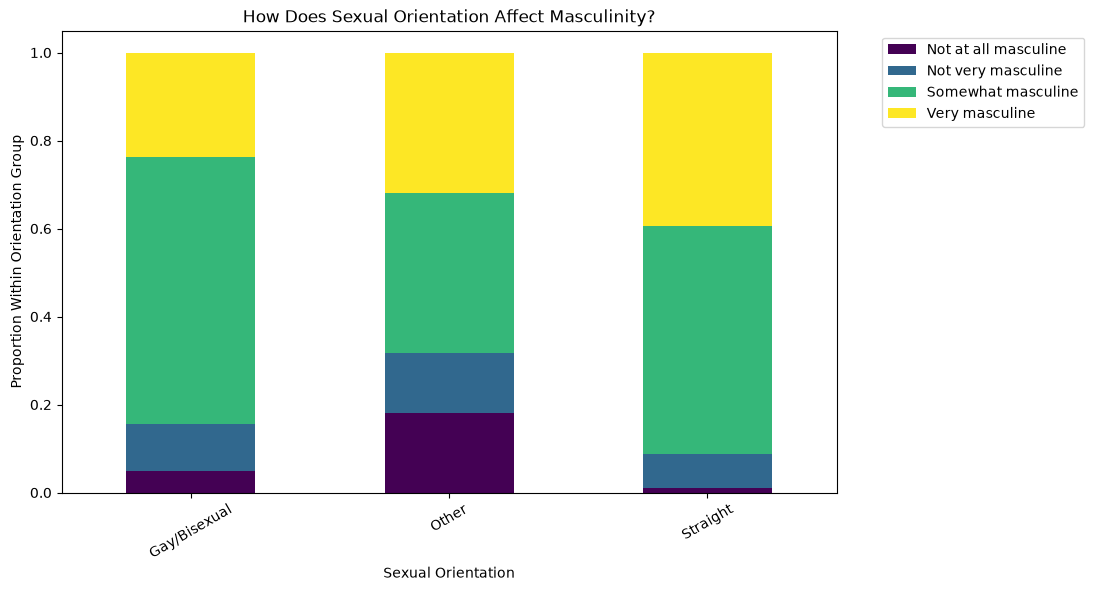

In [89]:
# The sexual orientation-masculinity relationship
orientation_columns = ['orientation_Gay/Bisexual', 'orientation_Other', 'orientation_Straight']
orientation_status = survey_subset1[orientation_columns].idxmax(axis=1).str.replace('orientation_', '', regex=False)
orientation_proportions = pd.crosstab(orientation_status, survey_subset1['q0001'], normalize='index')
orientation_proportions.columns = ['Not at all masculine', 'Not very masculine', 'Somewhat masculine', 'Very masculine']
orientation_proportions.plot(kind='bar',
                             stacked=True,
                             figsize=(10, 6),
                             colormap='viridis')
plt.xlabel('Sexual Orientation')
plt.ylabel('Proportion Within Orientation Group')
plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
plt.title('How Does Sexual Orientation Affect Masculinity?')
plt.xticks(rotation=30)
plt.show()

#### Train the Unsupervised Models

In [90]:
from sklearn.cluster import KMeans
classifier = KMeans(n_clusters=4)
classifier.fit(survey_subset1)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 15)"

In [94]:
print(classifier.cluster_centers_)

[[ 6.51006711e-01  9.46308725e-01  2.22818792e+00  1.54362416e-01
   5.50335570e-01  2.41610738e-01  2.01342282e-02  3.35570470e-02
   2.01342282e-01  2.14765101e-01  5.83892617e-01 -1.11022302e-16
   1.14093960e-01  2.01342282e-02  8.65771812e-01]
 [ 8.43478261e-01  2.00000000e+00  2.37826087e+00  3.04347826e-02
   8.58695652e-01  2.77555756e-17  8.69565217e-03  1.02173913e-01
   1.08695652e-02  1.52173913e-02  6.52173913e-03  9.67391304e-01
   2.82608696e-02  4.34782609e-03  9.67391304e-01]
 [ 3.65591398e-01  1.22580645e+00  2.01433692e+00  4.26523297e-01
   1.79211470e-02  4.58781362e-01  2.50896057e-02  7.16845878e-02
   1.07526882e-02  7.16845878e-03  3.58422939e-03  9.78494624e-01
   2.65232975e-01  5.73476703e-02  6.77419355e-01]
 [ 7.89855072e-01  9.56521739e-01  2.32246377e+00 -2.77555756e-17
   9.74637681e-01  3.62318841e-03  1.44927536e-02  7.24637681e-03
  -6.93889390e-18  0.00000000e+00 -4.16333634e-17  1.00000000e+00
   6.52173913e-02  3.62318841e-03  9.31159420e-01]]


In [91]:
cluster_zero_indices = []
cluster_one_indices = []
cluster_two_indices = []
cluster_three_indices = []
for i in range(len(classifier.labels_)):
    if classifier.labels_[i]==0:
        cluster_zero_indices.append(i)
    elif classifier.labels_[i]==1:
        cluster_one_indices.append(i)
    elif classifier.labels_[i]==2:
        cluster_two_indices.append(i)
    elif classifier.labels_[i]==3:
        cluster_three_indices.append(i)

In [119]:
cluster_zero_df = survey_subset1.iloc[cluster_zero_indices]
cluster_one_df = survey_subset1.iloc[cluster_one_indices]
cluster_two_df = survey_subset1.iloc[cluster_two_indices]
cluster_three_df = survey_subset1.iloc[cluster_three_indices]

In [122]:
cluster_profile = pd.DataFrame({'Cluster 0': cluster_zero_df.mean(),
                                'Cluster 1': cluster_one_df.mean(),
                                'Cluster 2': cluster_two_df.mean(),
                                'Cluster 3': cluster_three_df.mean()})
cluster_profile

,Cluster 0,Cluster 1,Cluster 2,Cluster 3
kids,0.651007,0.843478,0.365591,0.789855
age3,0.946309,2.000000,1.225806,0.956522
q0001,2.228188,2.378261,2.014337,2.322464
q0024_Divorced,0.154362,0.030435,0.426523,0.000000
q0024_Married,0.550336,0.858696,0.017921,0.974638
q0024_Never married,0.241611,0.000000,0.458781,0.003623
q0024_Separated,0.020134,0.008696,0.025090,0.014493
q0024_Widowed,0.033557,0.102174,0.071685,0.007246
racethn4_Black,0.201342,0.010870,0.010753,0.000000
racethn4_Hispanic,0.214765,0.015217,0.007168,0.000000
